# Fase 9 — Avaliação Quantitativa

Este notebook apresenta a avaliação offline do sistema híbrido de recomendação de filmes **Lord of the Cine**.

## Objetivo

O objetivo é comparar o **Popularity Baseline** com cinco configurações do recomendador híbrido. A análise utiliza Precision@10, Recall@10 e NDCG@10 para avaliar relevância e qualidade do ranqueamento, além de Coverage para medir a parcela do catálogo recomendada.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
RESULTS_PATH = PROJECT_ROOT / "reports" / "evaluation_results.csv"

results = pd.read_csv(RESULTS_PATH)
results

,Model,Precision@10,Recall@10,NDCG@10,Coverage,Evaluated Users,Skipped Users
0,Popularity Baseline,0.129048,0.106254,0.170644,0.005543,599,11
1,Hybrid 70/20/10,0.021202,0.030372,0.035923,0.084377,599,11
2,Hybrid 60/20/20,0.045910,0.055357,0.067296,0.060768,599,11
3,Hybrid 50/30/20,0.061603,0.071142,0.087618,0.048758,599,11
4,Hybrid 40/30/30,0.114357,0.109671,0.151283,0.028434,599,11
5,Hybrid 30/30/40,0.145743,0.127759,0.194200,0.015397,599,11


## Tabela de resultados

A tabela contém exclusivamente os valores produzidos pelo protocolo de avaliação da Fase 9.

In [2]:
metric_columns = ["Precision@10", "Recall@10", "NDCG@10", "Coverage"]
display(results.style.format({metric: "{:.4f}" for metric in metric_columns}))

,Model,Precision@10,Recall@10,NDCG@10,Coverage,Evaluated Users,Skipped Users
0,Popularity Baseline,0.1290,0.1063,0.1706,0.0055,599,11
1,Hybrid 70/20/10,0.0212,0.0304,0.0359,0.0844,599,11
2,Hybrid 60/20/20,0.0459,0.0554,0.0673,0.0608,599,11
3,Hybrid 50/30/20,0.0616,0.0711,0.0876,0.0488,599,11
4,Hybrid 40/30/30,0.1144,0.1097,0.1513,0.0284,599,11
5,Hybrid 30/30/40,0.1457,0.1278,0.1942,0.0154,599,11


## Comparação individual das métricas

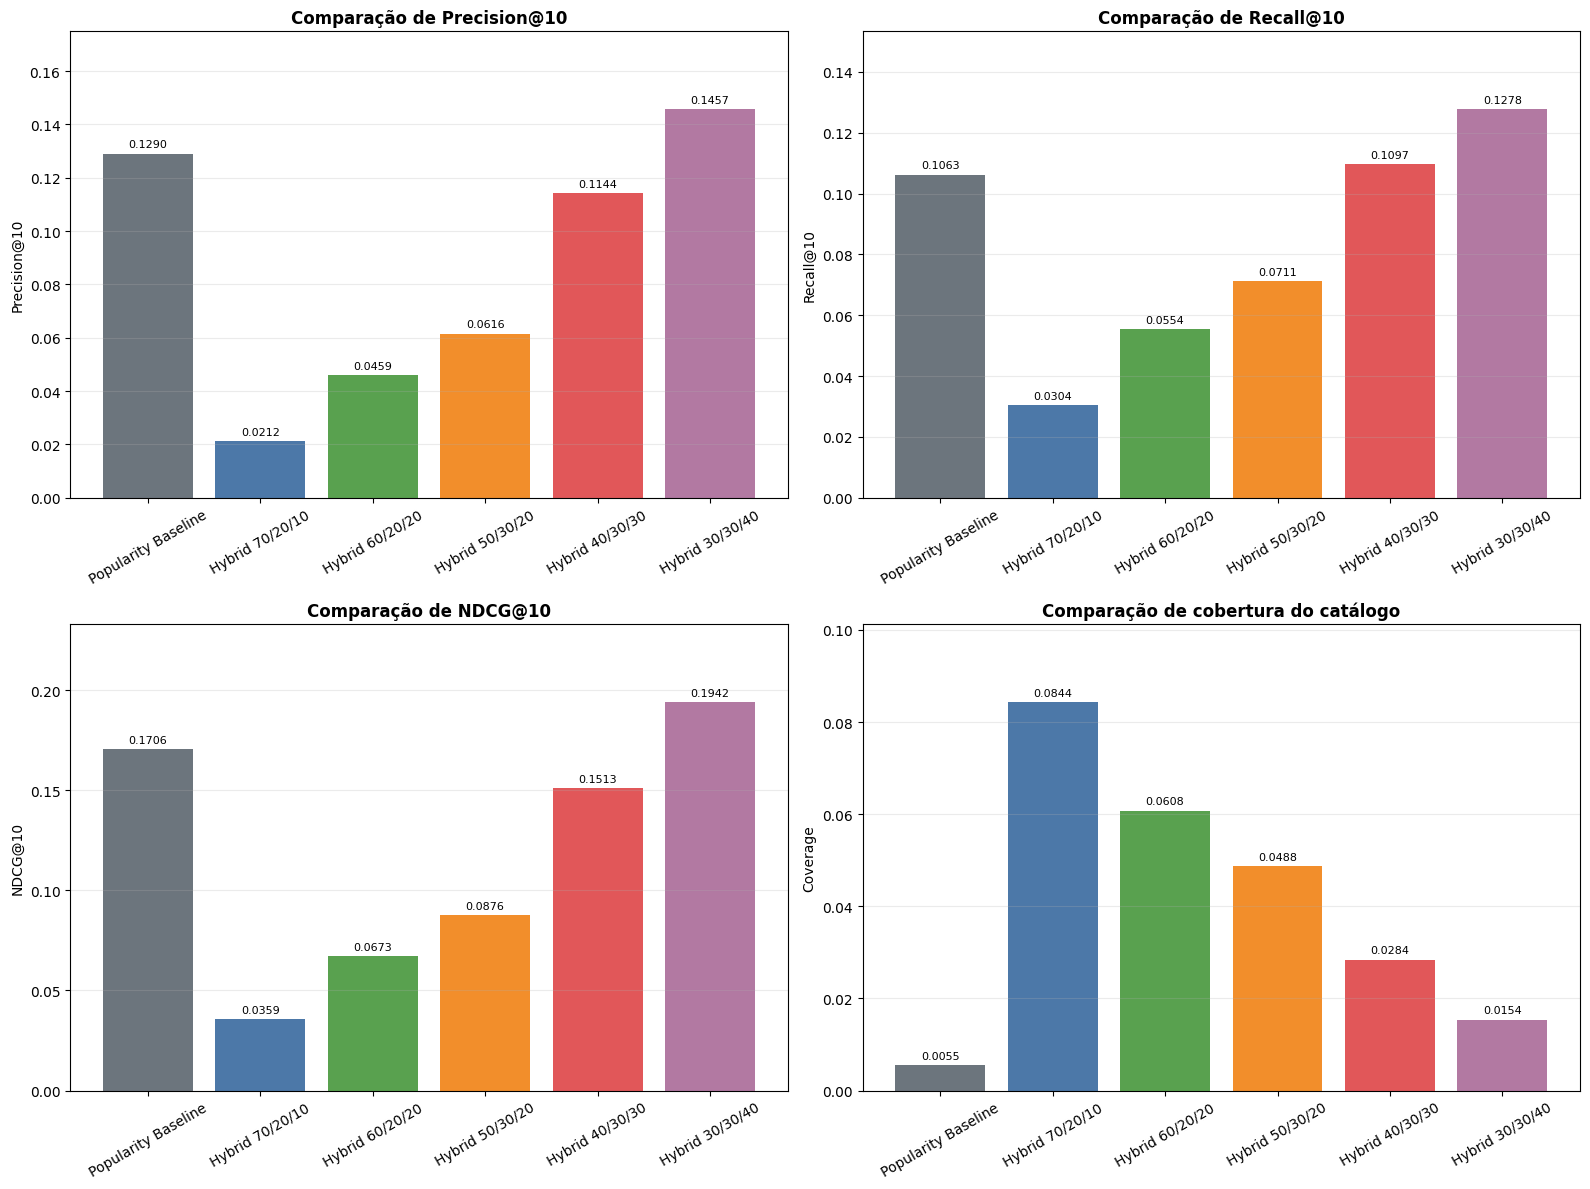

In [3]:
titles = {
    "Precision@10": "Comparação de Precision@10",
    "Recall@10": "Comparação de Recall@10",
    "NDCG@10": "Comparação de NDCG@10",
    "Coverage": "Comparação de cobertura do catálogo",
}
colors = ["#6C757D", "#4C78A8", "#59A14F", "#F28E2B", "#E15759", "#B279A2"]

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
for ax, metric in zip(axes.flat, metric_columns):
    bars = ax.bar(results["Model"], results[metric], color=colors)
    ax.set_title(titles[metric], fontweight="bold")
    ax.set_ylabel(metric)
    ax.set_ylim(0, results[metric].max() * 1.20)
    ax.tick_params(axis="x", rotation=30)
    ax.grid(axis="y", alpha=0.25)
    ax.bar_label(bars, fmt="%.4f", padding=3, fontsize=8)

fig.tight_layout()
plt.show()

## Comparação agrupada

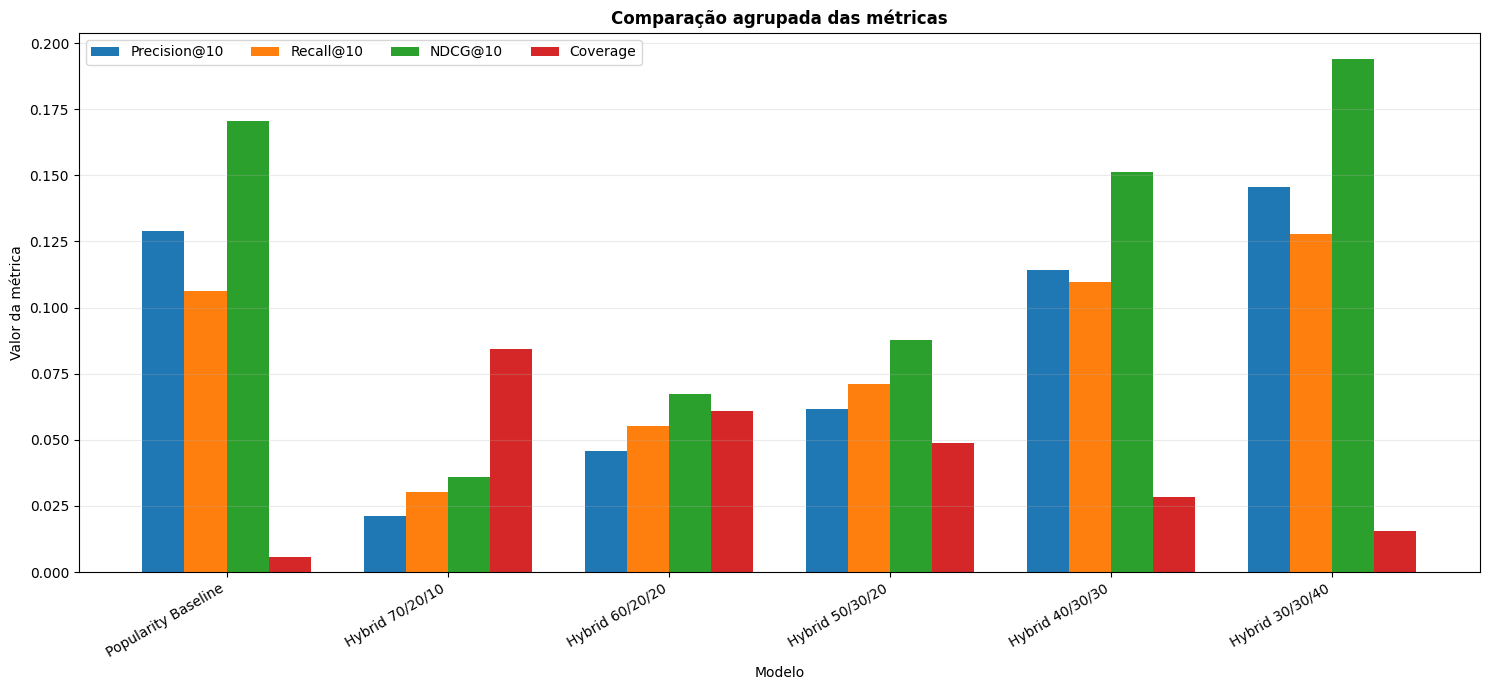

In [4]:
x = np.arange(len(results))
bar_width = 0.19

fig, ax = plt.subplots(figsize=(15, 7))
for index, metric in enumerate(metric_columns):
    offset = (index - 1.5) * bar_width
    ax.bar(x + offset, results[metric], bar_width, label=metric)

ax.set_title("Comparação agrupada das métricas", fontweight="bold")
ax.set_xlabel("Modelo")
ax.set_ylabel("Valor da métrica")
ax.set_xticks(x)
ax.set_xticklabels(results["Model"], rotation=30, ha="right")
ax.grid(axis="y", alpha=0.25)
ax.legend(ncol=4)
fig.tight_layout()
plt.show()

## Análise dos resultados

O **Popularity Baseline** obteve Precision@10 de **0.1290**, Recall@10 de **0.1063** e NDCG@10 de **0.1706**, demonstrando que a popularidade global é uma referência competitiva.

O **Hybrid 30/30/40** apresentou os melhores resultados de relevância: Precision@10 de **0.1457**, Recall@10 de **0.1278** e NDCG@10 de **0.1942**. Portanto, essa configuração superou o baseline nas três métricas.

O **Hybrid 70/20/10** alcançou a maior cobertura, com Coverage de **0.0844**. Os resultados mostram que o aumento do peso da popularidade melhora as métricas de precisão, enquanto o aumento do peso do perfil do usuário amplia a cobertura do catálogo. Esse comportamento caracteriza um trade-off entre relevância e diversidade.

## Conclusão da Fase 9

A avaliação quantitativa confirma que a configuração **Hybrid 30/30/40** é a melhor escolha quando o objetivo principal é maximizar Precision@10, Recall@10 e NDCG@10. Para ampliar a diversidade e a exposição do catálogo, a configuração **Hybrid 70/20/10** é a mais adequada.

A Fase 9 é concluída com um protocolo reprodutível, comparação com baseline, análise de múltiplas configurações híbridas e documentação do trade-off entre precisão e cobertura.